In [1]:
# Figure 8

import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

plt.rc('font',**{'family':'sans-serif','sans-serif':['DejaVu Sans'],'size':15})
plt.rc('mathtext',**{'default':'regular'})
plt.rc('axes',linewidth=2)
%matplotlib inline
%config InlineBackend.figure_format='retina'


In [2]:

dss = xr.open_dataset('/work/Chiung-Yin.Chang/CPT_Review/ocean_annual_z.static.nc')
dsg = xr.open_dataset('/work/Chiung-Yin.Chang/CPT_Review/ocean_hgrid.nc')
xh, yh = dsg.x[1::2,1::2], dsg.y[1::2,1::2]


In [3]:

arch = '/work/Chiung-Yin.Chang/CPT_Review/GFDL/'
run = 'REF/'
run_BS = 'BS/'
run_BSV = 'BSV/'

f_thetao='1990-2009.ocean_annual_z.thetao.nc'

ds_ref=xr.open_dataset(arch + run + f_thetao).mean(dim='time')
ds_BS=xr.open_dataset(arch + run_BS + f_thetao).mean(dim='time')
ds_BSV=xr.open_dataset(arch + run_BSV + f_thetao).mean(dim='time')


In [4]:

# This opens the PCMDI observation files

dso = xr.open_dataset('/work/Chiung-Yin.Chang/CPT_Review/tos_input4MIPs_SSTsAndSeaIce_CMIP_PCMDI-AMIP-1-1-8_gn_187001-202112.nc')
dsom = xr.open_dataset('/work/Chiung-Yin.Chang/CPT_Review/sftof_input4MIPs_SSTsAndSeaIce_CMIP_PCMDI-AMIP-1-1-8_gn.nc')
dso = dso.assign_coords(lon=( dso.lon + 300 )% 360 - 300).roll(lon=300,roll_coords=True)
dsom = dsom.assign_coords(lon=( dsom.lon + 300 )% 360 - 300).roll(lon=300,roll_coords=True)
ds_obs=dso.tos.where(dsom.sftof>0).isel(time=slice(1440,1680)).mean(dim='time') # select 1990-2009
sst_obs = ds_obs.interp(lon=np.mod(xh+300,360)-300, lat=yh)


In [14]:
import string

/vftmp/Wenda.Zhang/pid2164673/ipykernel_3429318/3895446974.py:54: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])  # leave space for colorbar


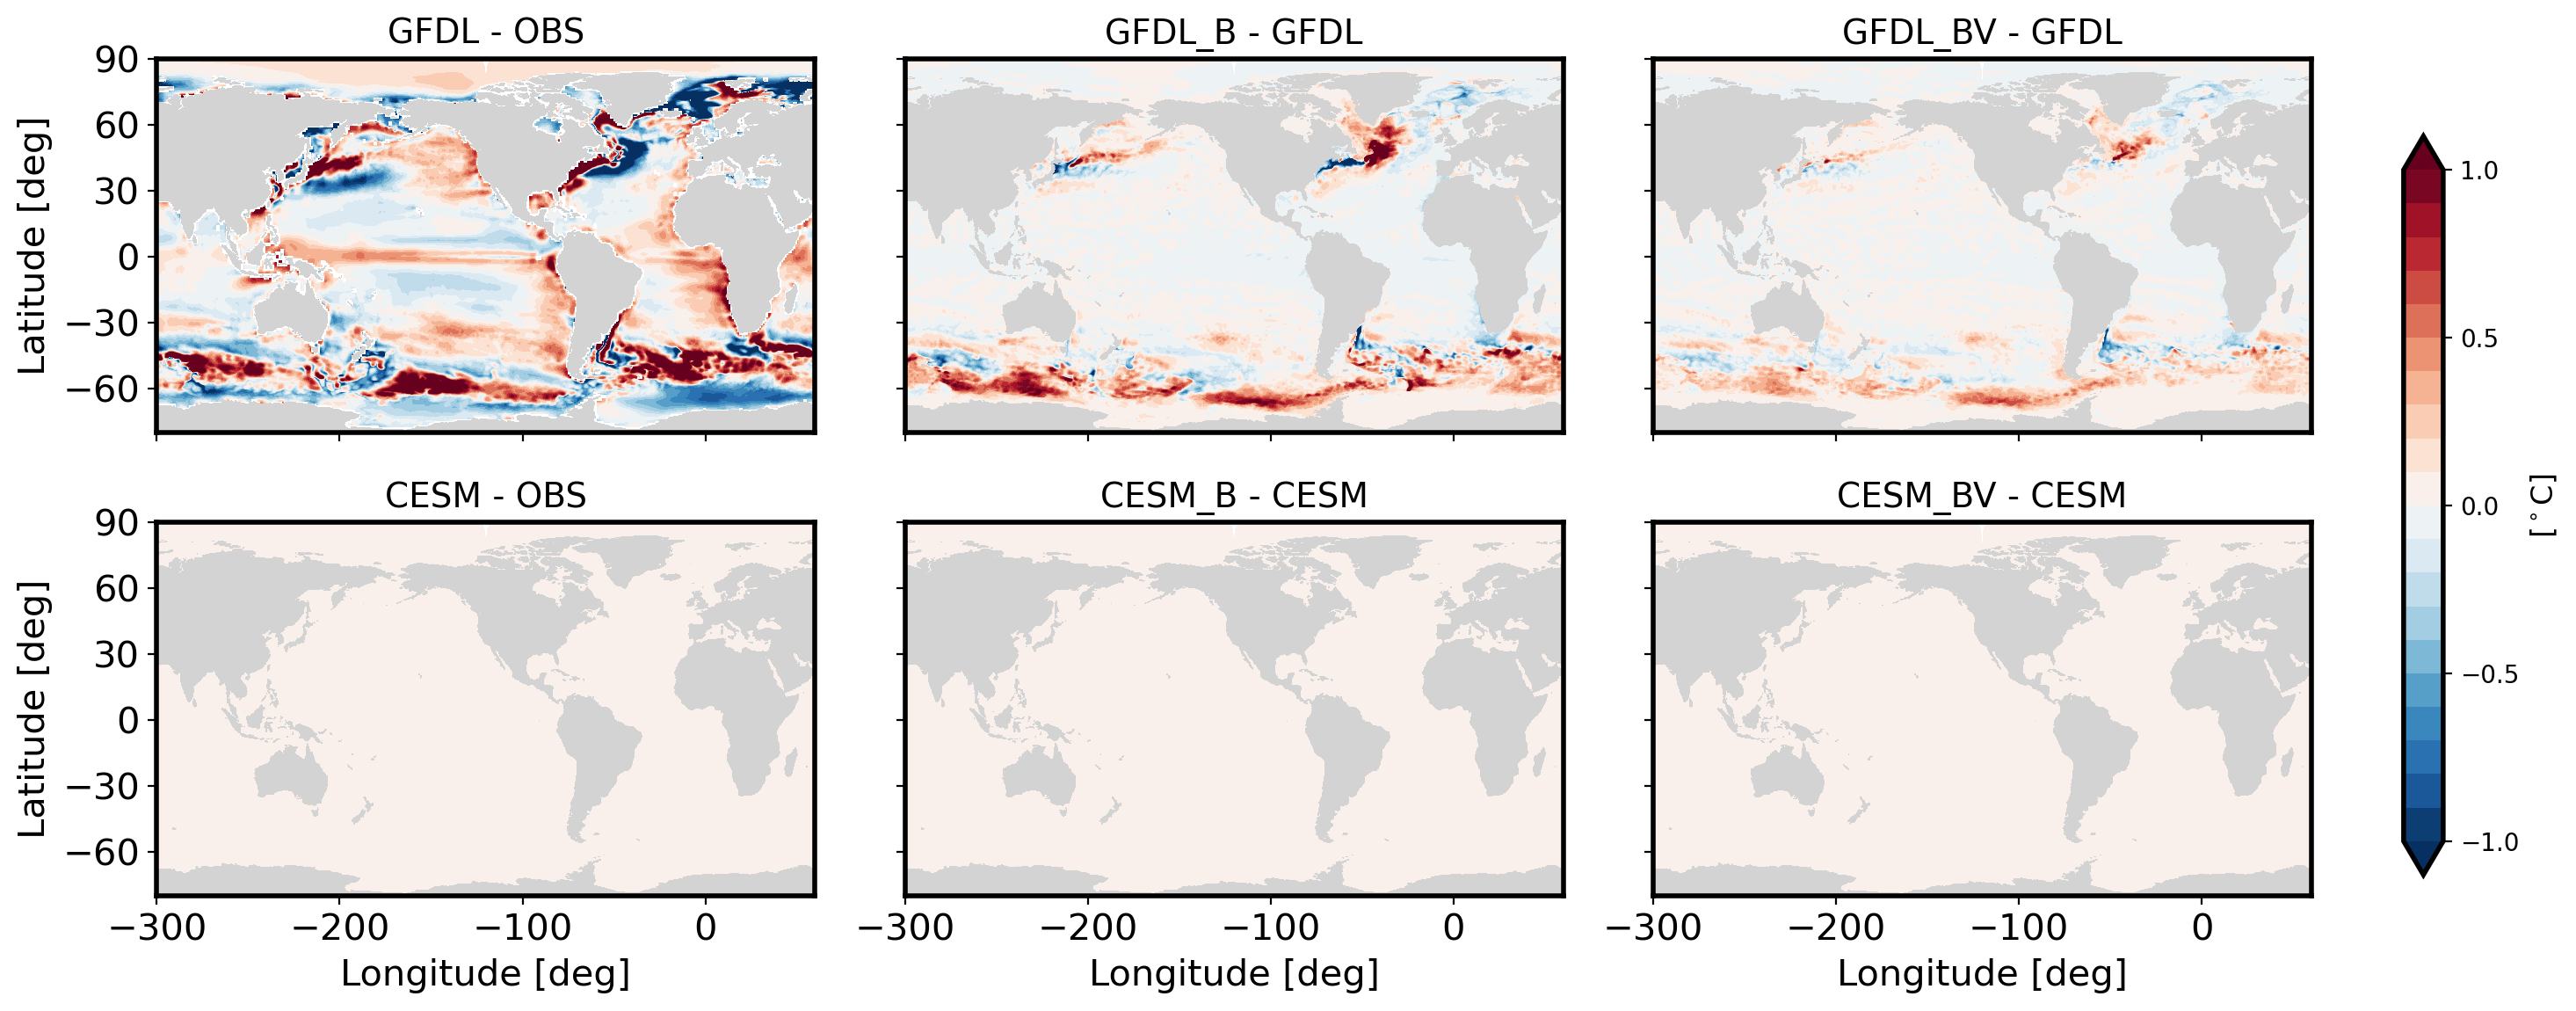

In [17]:
levels = np.arange(-4, 30, 1)
cmap = 'jet'
alevels = np.arange(-1., 1.1, 0.1)
acmap = 'RdBu_r'

fig, axes = plt.subplots(2, 3, figsize=(15, 6), sharex=True, sharey=True)

datasets = [
    (ds_ref.thetao[0,:,:]-sst_obs.values, "GFDL - OBS"),
    (ds_BS.thetao[0,:,:]-ds_ref.thetao[0,:,:], "GFDL_B - GFDL"),
    (ds_BSV.thetao[0,:,:]-ds_ref.thetao[0,:,:], "GFDL_BV - GFDL"),
    (xh*0, "CESM - OBS"),
    (xh*0, "CESM_B - CESM"),
    (xh*0, "CESM_BV - CESM")
]

im = None
letters = list(string.ascii_lowercase)
for i, ax in enumerate(axes.flat):
    field, title = datasets[i]
    im = ax.contourf(xh, yh, field, levels=alevels, cmap=acmap, extend='both')
    ax.contourf(xh, yh, dss.wet, levels=[0, 0.001], colors='lightgray', extend='min')
    
    # Row and column index
    row, col = divmod(i, 3)
    
    # Only left column gets y-labels
    if col == 0:
        ax.set_ylabel("Latitude [deg]")
    
    # Only bottom row gets x-labels
    if row == 1:
        ax.set_xlabel("Longitude [deg]")
        
    # ax.annotate(
    #     f"({letters[i]})",
    #     xy=(0, 1), xycoords="axes fraction",
    #     xytext=(-35, 5), textcoords="offset points",
    #     ha="right", va="bottom",
    #     fontsize=12, fontweight="bold"
    # )
        
    ax.set_xlim([-300, 60])
    ax.set_ylim([-80, 90])
    ax.set_yticks(np.arange(-60, 100, 30))
    ax.set_title(title, fontsize=14)

# Single shared colorbar on the right
cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])  # [left, bottom, width, height]
cbar = fig.colorbar(im, cax=cbar_ax, ticks=[-1,-0.5,0,0.5,1])
cbar.set_label(r"[$^\circ$C]", fontsize=12)
cbar.ax.tick_params(labelsize=10)

plt.tight_layout(rect=[0, 0, 0.9, 1])  # leave space for colorbar
# fig.savefig("Figure_CPT_review/GCM_SST.pdf", dpi=800)
# plt.show()
